# Explanatory Data Analysis

In [ ]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
from pathlib import Path

# Path.cwd() gets the 'modeling' directory, and .parent moves up to the project root
project_root = Path.cwd().parent

# The division operator (/) is used by pathlib to join paths safely on any OS
tx_path = project_root / "lakehouse" / "silver" / "transactions_history.parquet"
outlets_path = project_root / "lakehouse" / "silver" / "outlet_master.parquet"

# Load the datasets
tx = pd.read_parquet(tx_path)
outlets = pd.read_parquet(outlets_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [22]:
# Display the first few rows of the transactions dataset
print("Transactions Dataset:")
tx.head()

Transactions Dataset:


,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value,_ingested_at,_source_file
0,OUT_19886,2024,12,DIST_S_02,SKU_10,5.897879,2177.632359,2026-05-16 20:00:08.676753,data/transactions_history_final.csv
1,OUT_00837,2024,2,DIST_W_01,SKU_03,20.697364,7244.084814,2026-05-16 20:00:08.676753,data/transactions_history_final.csv
2,OUT_15438,2025,12,DIST_NW_01,SKU_02,55.101801,13959.108787,2026-05-16 20:00:08.676753,data/transactions_history_final.csv
3,OUT_12992,2025,1,DIST_C_01,SKU_07,24.063953,15641.548773,2026-05-16 20:00:08.676753,data/transactions_history_final.csv
4,OUT_12334,2025,5,DIST_C_02,SKU_04,47.769665,15525.158656,2026-05-16 20:00:08.676753,data/transactions_history_final.csv


In [19]:
# Check the data types of the transactions dataset
print("\nTransactions Dataset Info:")
tx.info()


Transactions Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2334830 entries, 0 to 2334829
Data columns (total 9 columns):
 #   Column            Dtype         
---  ------            -----         
 0   Outlet_ID         str           
 1   Year              int64         
 2   Month             int64         
 3   Distributor_ID    str           
 4   SKU_ID            str           
 5   Volume_Liters     float64       
 6   Total_Bill_Value  float64       
 7   _ingested_at      datetime64[us]
 8   _source_file      str           
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 292.1 MB


In [23]:
# Display the first few rows of the outlets dataset
print("\nOutlets Dataset:")
outlets.head()


Outlets Dataset:


,Outlet_ID,Outlet_Size,Cooler_Count,Outlet_Type,_ingested_at,_source_file
0,OUT_00001,Medium,1,Grocery,2026-05-16 20:00:05.546363,data/outlet_master.csv
1,OUT_00002,Small,0,Hotel,2026-05-16 20:00:05.546363,data/outlet_master.csv
2,OUT_00003,Small,1,Pharmacy,2026-05-16 20:00:05.546363,data/outlet_master.csv
3,OUT_00004,Medium,2,Pharmacy,2026-05-16 20:00:05.546363,data/outlet_master.csv
4,OUT_00005,Medium,2,Kiosk,2026-05-16 20:00:05.546363,data/outlet_master.csv


In [20]:
# Data types of the outlets dataset
print("\nOutlets Dataset Info:")
outlets.info()


Outlets Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 19764 entries, 0 to 19763
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Outlet_ID     19764 non-null  string        
 1   Outlet_Size   19764 non-null  category      
 2   Cooler_Count  19764 non-null  int64         
 3   Outlet_Type   19764 non-null  category      
 4   _ingested_at  19764 non-null  datetime64[us]
 5   _source_file  19764 non-null  str           
dtypes: category(2), datetime64[us](1), int64(1), str(1), string(1)
memory usage: 1.2 MB


## Data visualization

In [58]:
# Volume Distribution
monthly_sales = tx.groupby(['Outlet_ID', 'Year', 'Month'])['Volume_Liters'].sum().reset_index()

# Monthly volume per outlet

monthly_vol = monthly_sales.groupby(['Outlet_ID', 'Month'])['Volume_Liters'].sum().reset_index()

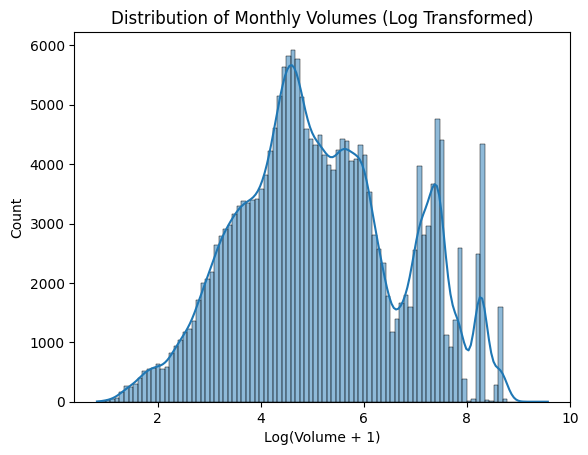

In [64]:
# Distribution of monthly volumes
log_monthly_vol = np.log1p(monthly_vol['Volume_Liters'])
sns.histplot(log_monthly_vol, bins=100, kde=True)
plt.title('Distribution of Monthly Volumes (Log Transformed)')
plt.xlabel('Log(Volume + 1)')
plt.show()



In [66]:
# Discovering how many months of history does each outlet have

outlet_months = monthly_sales.groupby('Outlet_ID')['Month'].nunique().reset_index()
print(outlet_months.describe())

              Month
count  19960.000000
mean      11.071293
std        1.147989
min        4.000000
25%       10.000000
50%       11.000000
75%       12.000000
max       12.000000


In [69]:
# Discovering what fraction of outlets look constrained

outlet_stats = monthly_sales.groupby('Outlet_ID')['Volume_Liters'].agg(['mean', 'std', 'min', 'max']).reset_index()
outlet_stats['cv'] = outlet_stats['std'] / (outlet_stats['mean'] + 1e-8)  # Adding a small constant to avoid division by zero

# Low CV + high utilization → likely constrained (hitting same ceiling repeatedly)
print(f"Outlets with CV < 0.1: {(outlet_stats['cv'] < 0.1).sum()}")
# These are suspicious — real demand fluctuates, constant sales = credit cap

Outlets with CV < 0.1: 0


                   mean      median           max
Outlet_Type                                      
Pharmacy     591.846434  158.362814   6138.737069
Kiosk        578.313213  160.552166   6150.426085
Hotel        574.740066  156.327427   6228.244389
Eatery       562.700278  156.846442   6115.969218
Grocery      562.505991  156.603420  14383.265943
Bakery       557.502487  155.804129   6209.173679
SMMT         534.462665  150.016427   6088.003561


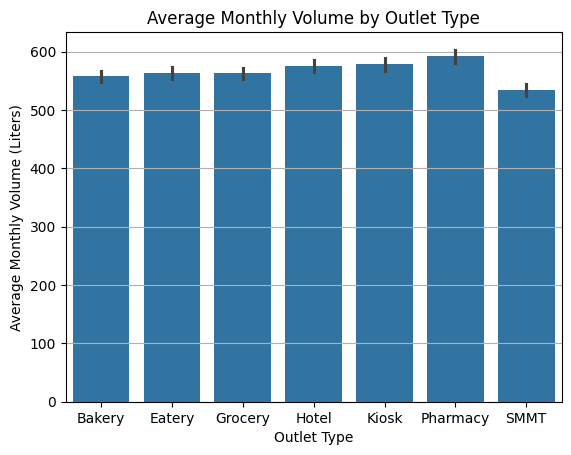

In [80]:
# 4. Volume by outlet type
vol_by_type = monthly_vol.merge(
    outlets[['Outlet_ID', 'Outlet_Type']], on='Outlet_ID'
).groupby('Outlet_Type')['Volume_Liters'].agg(['mean', 'median', 'max'])
print(vol_by_type.sort_values('mean', ascending=False))

sns.barplot(x='Outlet_Type', y='Volume_Liters', data=monthly_vol.merge(outlets[['Outlet_ID', 'Outlet_Type']], on='Outlet_ID'))
plt.title('Average Monthly Volume by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Average Monthly Volume (Liters)')
plt.grid(True, axis='y')
plt.show()

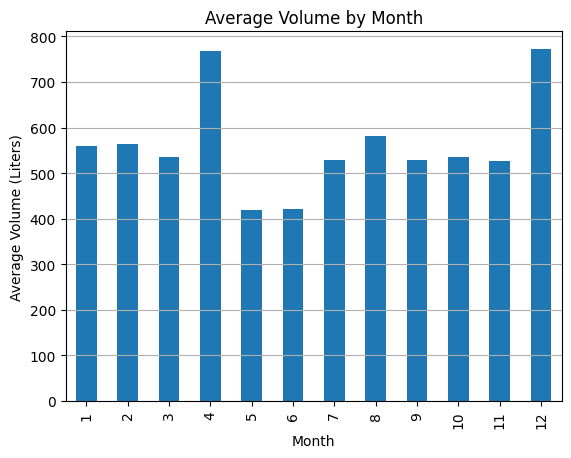

In [81]:
# Descovering seasonal patterns
monthly_sales['month_num'] = monthly_sales['Month'].astype(int)  # Ensure month is numeric
seasonal = monthly_sales.groupby('month_num')['Volume_Liters'].mean()
seasonal.plot(kind='bar')
plt.title("Average Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume (Liters)")
plt.grid(True, axis='y')
plt.show()